# 생활폐기물 분류 - B1 베이스라인 학습
- 단일 모달 이미지 분류 (23개 그룹)
- Kaggle EfficientNet-B0



## 0. 환경 설정

In [ ]:
!pip install tf_keras tensorflow_hub -q
!pip install scikit-learn -q

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub
import tensorflow as tf

from sklearn.metrics import accuracy_score, f1_score, classification_report

print('TensorFlow 버전:', tf.__version__)
print('GPU 사용 가능:', tf.config.list_physical_devices('GPU'))

TensorFlow 버전: 2.20.0
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 구글 드라이브 마운트 및 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = '/content/drive/MyDrive/multimodel_recycle/output'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
VAL_CSV = os.path.join(BASE_DIR, 'val.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test.csv')

# 하이퍼파라미터
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 2e-5
NUM_CLASS = 23
SEED = 42

GROUP_NAMES = {
    0:  '종이',
    1:  '종이팩',
    2:  '종이컵',
    3:  '캔',
    4:  '재사용유리',
    5:  '유리',
    6:  '페트',
    7:  '플라스틱',
    8:  '비닐',
    9:  '종이+이물질',
    10: '종이컵+이물질',
    11: '캔+이물질',
    12: '유리+이물질',
    13: '페트+이물질+다중포장재',
    14: '페트+이물질',
    15: '플라스틱+이물질',
    16: '비닐+이물질',
    17: '재사용유리+다중포장재',
    18: '유리+다중포장재',
    19: '페트+다중포장재',
    20: '스티로폼',
    21: '스티로폼+이물질',
    22: '건전지',
}

print('경로 설정 완료')

경로 설정 완료


## 2. 데이터 로드 및 경로변환

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

# 로컬 상대경로 -> 드라이브 절대경로 변환
IMG_DIR = os.path.join(BASE_DIR, 'images')
def fix_path(x):
    filename = x.replace('\\', '/').split('/')[-1]
    return os.path.join(IMG_DIR, filename)

train_df['img_path'] = train_df['img_path'].apply(fix_path)
val_df['img_path']   = val_df['img_path'].apply(fix_path)
test_df['img_path']  = test_df['img_path'].apply(fix_path)

print(f'Train: {len(train_df)}장')
print(f'Val:   {len(val_df)}장')
print(f'Test:  {len(test_df)}장')

Train: 17250장
Val:   3450장
Test:  2300장


## 3. Dataset 생성

In [ ]:
# 전처리에서 이미 224x224로 저장되어 있으므로 리사이즈 불필요
def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label

def make_dataset(df, shuffle=False):
    paths  = df['img_path'].values
    labels = df['group_id'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)
print('Dataset 생성 완료')

Dataset 생성 완료


## 4. B1 모델 구성 (전이학습 - EfficientNet 백본 동결, 분류 헤드 학습)

In [ ]:
# Keras 내장 EfficientNet-B0 로드
backbone = keras.applications.EfficientNetB0(include_top=False, pooling=None)
backbone.trainable = False


inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = backbone(inputs)  # (batch, 1280)
x = layers.GlobalAveragePooling2D()(x)   # (batch, 1280)

# 분류 헤드
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASS, activation='softmax')(x)

model_b1 = keras.Model(inputs, outputs, name='B1_EfficientNet')
model_b1.summary()

Model: "B1_EfficientNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 23)            

## 5. 모델 학습

In [ ]:
model_b1.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('b1_best.keras', save_best_only=True, monitor='val_loss'),
]

hist = model_b1.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/30
1079/1079 [==============================] - 740s 579ms/step - loss: 2.8013 - accuracy: 0.1995 - val_loss: 2.3631 - val_accuracy: 0.3658
Epoch 2/30
1079/1079 [==============================] - 24s 21ms/step - loss: 2.2406 - accuracy: 0.3626 - val_loss: 1.9581 - val_accuracy: 0.4432
Epoch 3/30
1079/1079 [==============================] - 24s 21ms/step - loss: 1.9561 - accuracy: 0.4230 - val_loss: 1.7405 - val_accuracy: 0.4910
Epoch 4/30
1079/1079 [==============================] - 24s 21ms/step - loss: 1.7889 - accuracy: 0.4612 - val_loss: 1.6065 - val_accuracy: 0.5214
Epoch 5/30
1079/1079 [==============================] - 24s 21ms/step - loss: 1.6861 - accuracy: 0.4874 - val_loss: 1.5162 - val_accuracy: 0.5426
Epoch 6/30
1079/1079 [==============================] - 24s 21ms/step - loss: 1.6059 - accuracy: 0.5016 - val_loss: 1.4521 - val_accuracy: 0.5554
Epoch 7/30
1079/1079 [==============================] - 24s 21ms/step - loss: 1.5383 - accuracy: 0.5224 - val_loss: 1.4005

## 6. 학습 곡선 시각화

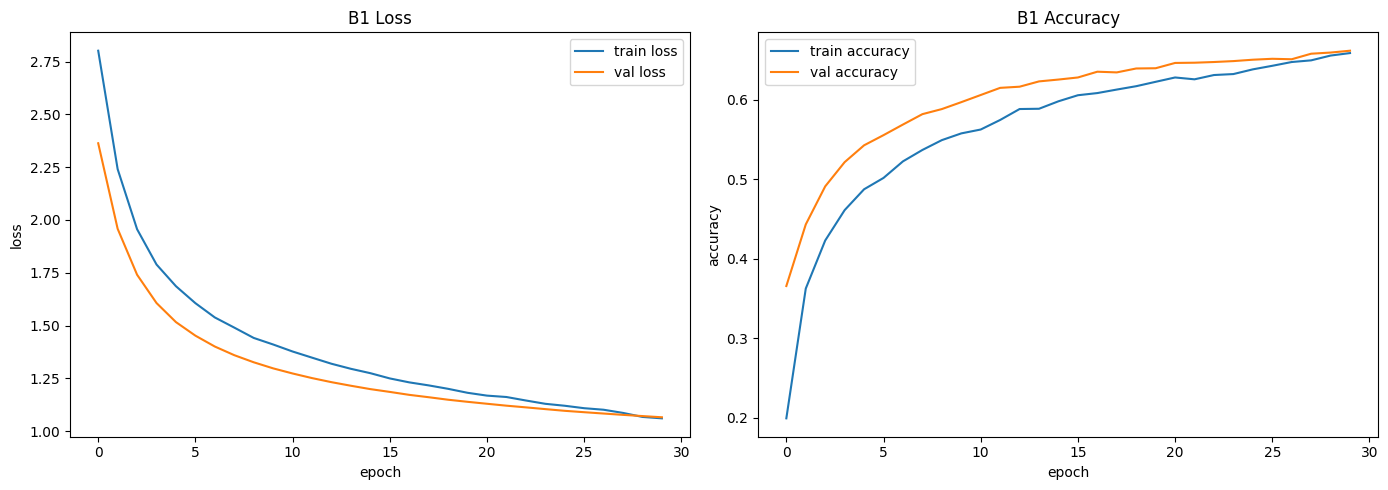

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(hist.history['loss'], label='train loss')
axs[0].plot(hist.history['val_loss'], label='val loss')
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].set_title('B1 Loss')
axs[0].legend()

axs[1].plot(hist.history['accuracy'], label='train accuracy')
axs[1].plot(hist.history['val_accuracy'], label='val accuracy')
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].set_title('B1 Accuracy')
axs[1].legend()

plt.tight_layout()
plt.savefig('b1_training_curve.png', dpi=150)
plt.show()

## 7. 성능 평가 및 저장

In [ ]:
model_b1 = keras.models.load_model('b1_best.keras', custom_objects={'KerasLayer': hub.KerasLayer})

y_pred = np.argmax(model_b1.predict(test_ds), axis=1)
y_true = test_df['group_id'].values

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print('=' * 40)
print('B1 테스트 성능')
print('=' * 40)
print(f'Accuracy: {accuracy:.4f}')
print(f'Macro F1: {macro_f1:.4f}')

# 결과 저장
pd.DataFrame([{'model': 'B1', 'accuracy': accuracy, 'macro_f1': macro_f1}]).to_csv(
    os.path.join(BASE_DIR, 'b1_results.csv'), index=False)
model_b1.save(os.path.join(BASE_DIR, 'b1_best.keras'))
print('저장 완료!')

144/144 [==============================] - 56s 374ms/step
B1 테스트 성능
Accuracy: 0.6522
Macro F1: 0.6503
저장 완료!
